In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error

In [36]:
df = pd.read_csv('coffee_shop_revenue.csv')

In [37]:
print(df.isnull().sum())

Number_of_Customers_Per_Day    0
Average_Order_Value            0
Operating_Hours_Per_Day        0
Number_of_Employees            0
Marketing_Spend_Per_Day        0
Location_Foot_Traffic          0
Daily_Revenue                  0
dtype: int64


# Data Preprocessing

## Data Quality Check
- Checked for missing values in the dataset
- No missing values were found

In [38]:
df.describe()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,274.296000,6.261215,11.667000,7.947000,252.614160,534.893500,1917.325940
std,129.441933,2.175832,3.438608,3.742218,141.136004,271.662295,976.202746
min,50.000000,2.500000,6.000000,2.000000,10.120000,50.000000,-58.950000
25%,164.000000,4.410000,9.000000,5.000000,130.125000,302.000000,1140.085000
50%,275.000000,6.300000,12.000000,8.000000,250.995000,540.000000,1770.775000
75%,386.000000,8.120000,15.000000,11.000000,375.352500,767.000000,2530.455000
max,499.000000,10.000000,17.000000,14.000000,499.740000,999.000000,5114.600000


## Data Cleaning
- Found negative values in `Daily_Revenue` column
- Negative revenue values are logically invalid
- Removing rows with negative revenue to maintain data quality

In [39]:
df = df[df['Daily_Revenue']>0]

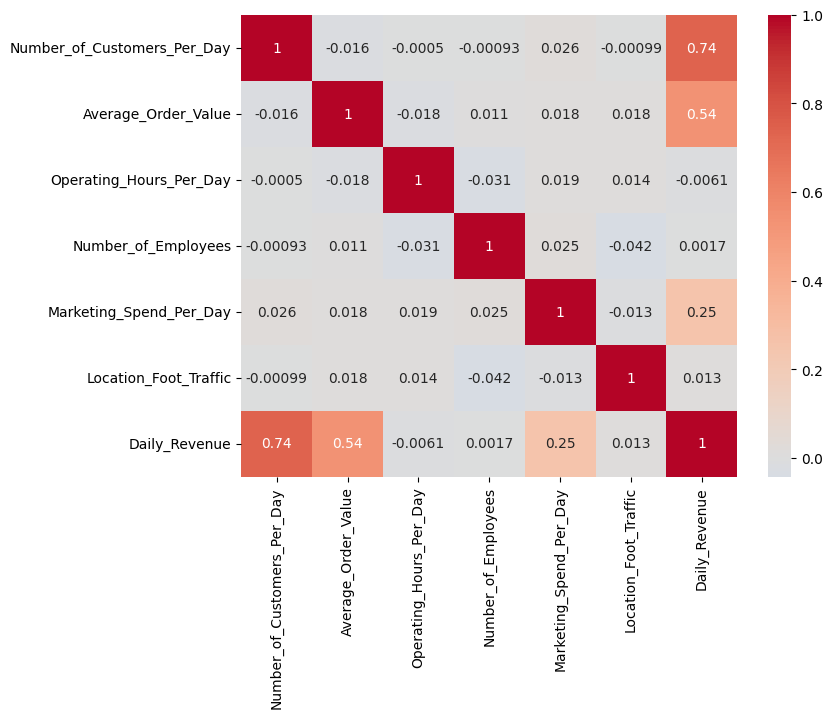

In [40]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
plt.show()

In [41]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = df[['Number_of_Customers_Per_Day', 'Average_Order_Value', 'Marketing_Spend_Per_Day']]  # use your actual feature names
X = add_constant(X)

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)


                      Variable        VIF
0                        const  16.822942
1  Number_of_Customers_Per_Day   1.000929
2          Average_Order_Value   1.000576
3      Marketing_Spend_Per_Day   1.001001


## Feature Analysis

Correlation Analysis Results:
1. Strong positive correlation identified between:
   - `Number_of_Customers_Per_Day` and `Daily_Revenue`
   - `Average_Order_Value` and `Daily_Revenue`

These features will be our primary predictors for revenue modeling.

In [42]:
X = df[['Number_of_Customers_Per_Day', 'Average_Order_Value', 'Marketing_Spend_Per_Day']]
y = df['Daily_Revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

## Feature Scaling

Feature value ranges:
- `Number_of_Customers_Per_Day`: [50, 499]
- `Average_Order_Value`: [2.5, 10]

Scaling is necessary to:
1. Prevent bias from different value ranges
2. Improve model convergence
3. Ensure equal feature importance weighting

In [43]:
# 1. For Linear Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
model_simple = LinearRegression()
model_simple.fit(X_train_scaled[:, [0]], y_train)  # Using first column only
y_pred_simple = model_simple.predict(X_test_scaled[:, [0]])
print("Simple R²:", r2_score(y_test, y_pred_simple))
print("Simple MSE:", mean_squared_error(y_test, y_pred_simple))


Simple R²: 0.5497867951668967
Simple MSE: 455703.6328995053


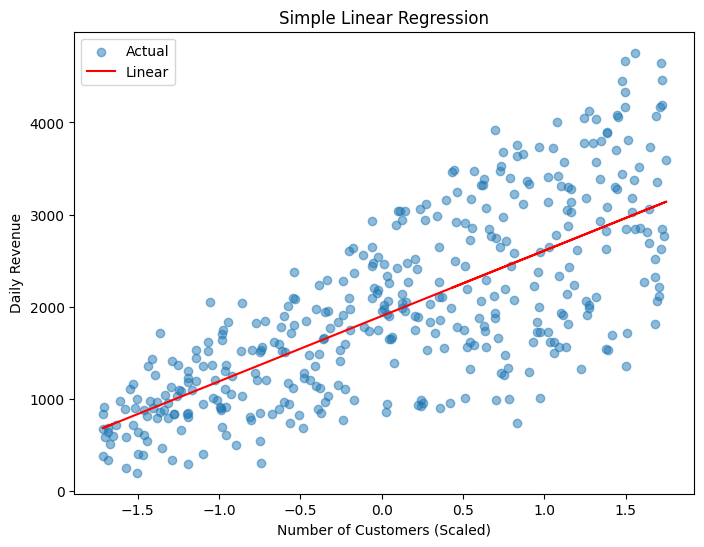

In [45]:
plt.figure(figsize=(8, 6))
plt.scatter(X_test_scaled[:, 0], y_test, alpha=0.5, label='Actual')
plt.plot(X_test_scaled[:, 0], y_pred_simple, color='red', label='Linear')
plt.xlabel('Number of Customers (Scaled)')
plt.ylabel('Daily Revenue')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()


In [46]:
model_multi = LinearRegression()
model_multi.fit(X_train_scaled, y_train)
y_pred_multi = model_multi.predict(X_test_scaled)  # Use scaled test data
print("Multi R²:", r2_score(y_test, y_pred_multi))
print("Multi MSE:", mean_squared_error(y_test, y_pred_multi))

Multi R²: 0.8953495856608084
Multi MSE: 105926.6442806513


# Model Performance Comparison

## Simple Linear Regression
- R²: 0.5498
- MSE: 455,703.63

## Multiple Linear Regression
- R²: 0.8953
- MSE: 105,926.644

## Analysis
The multiple linear regression model significantly outperforms the simple model:
- Higher R² indicates better fit (improved by 62.79%)
- Lower MSE shows better prediction accuracy (reduced by 76.76%)

This improvement demonstrates the importance of including both customer count and average order value as predictors.

# Polynomial Regression

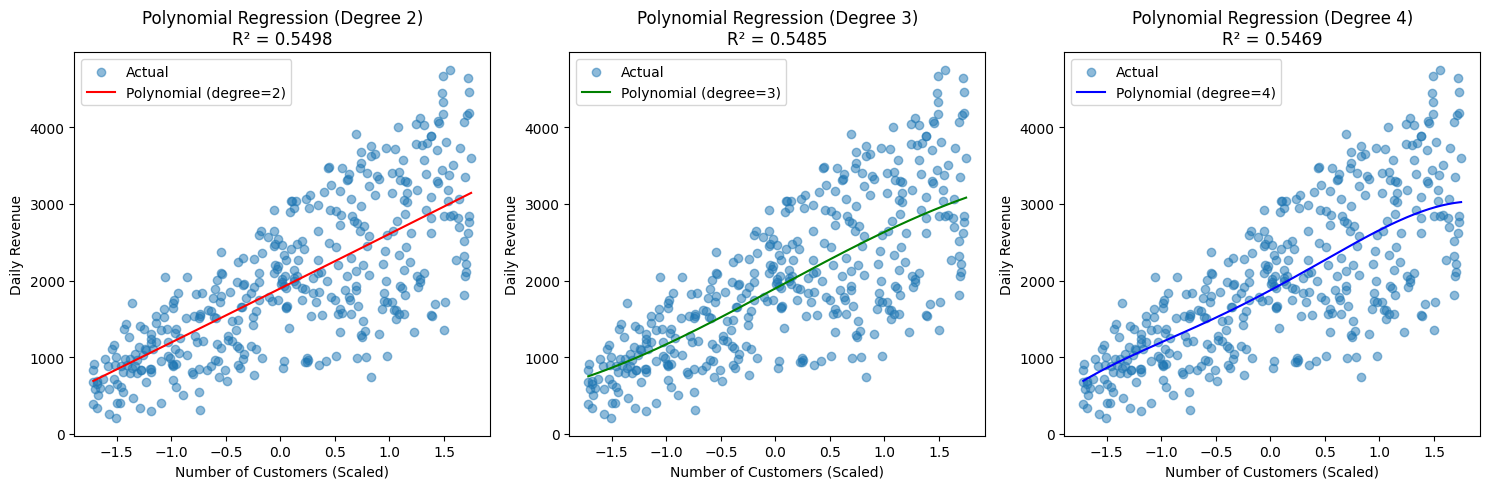

In [47]:
# Create polynomial features and models
poly2 = PolynomialFeatures(degree=2)
poly3 = PolynomialFeatures(degree=3)
poly4 = PolynomialFeatures(degree=4)

# Transform features
X_train_poly2 = poly2.fit_transform(X_train_scaled[:, [0]])
X_test_poly2 = poly2.transform(X_test_scaled[:, [0]])
X_train_poly3 = poly3.fit_transform(X_train_scaled[:, [0]])
X_test_poly3 = poly3.transform(X_test_scaled[:, [0]])
X_train_poly4 = poly4.fit_transform(X_train_scaled[:, [0]])
X_test_poly4 = poly4.transform(X_test_scaled[:, [0]])

# Fit models
model_poly2 = LinearRegression().fit(X_train_poly2, y_train)
model_poly3 = LinearRegression().fit(X_train_poly3, y_train)
model_poly4 = LinearRegression().fit(X_train_poly4, y_train)

# Get predictions
y_pred_poly2 = model_poly2.predict(X_test_poly2)
y_pred_poly3 = model_poly3.predict(X_test_poly3)
y_pred_poly4 = model_poly4.predict(X_test_poly4)

# Create figure for comparison
plt.figure(figsize=(15, 5))

# Sort for smooth line plotting
sort_idx = np.argsort(X_test_scaled[:, 0])

# Plot polynomial regression results
plt.subplot(1, 3, 1)
plt.scatter(X_test_scaled[:, 0], y_test, alpha=0.5, label='Actual')
plt.plot(X_test_scaled[sort_idx, 0], y_pred_poly2[sort_idx], color='red', label='Polynomial (degree=2)')
plt.xlabel('Number of Customers (Scaled)')
plt.ylabel('Daily Revenue')
plt.title('Polynomial Regression (Degree 2)\nR² = {:.4f}'.format(r2_score(y_test, y_pred_poly2)))
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(X_test_scaled[:, 0], y_test, alpha=0.5, label='Actual')
plt.plot(X_test_scaled[sort_idx, 0], y_pred_poly3[sort_idx], color='green', label='Polynomial (degree=3)')
plt.xlabel('Number of Customers (Scaled)')
plt.ylabel('Daily Revenue')
plt.title('Polynomial Regression (Degree 3)\nR² = {:.4f}'.format(r2_score(y_test, y_pred_poly3)))
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(X_test_scaled[:, 0], y_test, alpha=0.5, label='Actual')
plt.plot(X_test_scaled[sort_idx, 0], y_pred_poly4[sort_idx], color='blue', label='Polynomial (degree=4)')
plt.xlabel('Number of Customers (Scaled)')
plt.ylabel('Daily Revenue')
plt.title('Polynomial Regression (Degree 4)\nR² = {:.4f}'.format(r2_score(y_test, y_pred_poly4)))
plt.legend()

plt.tight_layout()
plt.show()

# Polynomial Regression Model Comparison

## Performance Metrics
| Model | R² Score | MSE |
|-------|----------|-----|
| Polynomial (degree=2) | 0.5498 | 455,666.40 |
| Polynomial (degree=3) | 0.5485 | 457,038.43 |
| Polynomial (degree=4) | 0.5469 | 458,661.24 |

## Analysis
1. Higher degree polynomials did not improve model performance
2. The quadratic model (degree=2) performed slightly better than higher degrees
3. The complexity added by higher degrees may be leading to overfitting